# Air Quality Analytics Report

This notebook summarizes the curated Sofia AQI dataset using the shared Spark batch analytics pipeline in `src/analytics/`.

It loads the report tables once, converts them to pandas for presentation, and closes the Spark session automatically.

## Source and Report Scope

Curated source path:

`hdfs://namenode:9000/data/air-quality/<CITY>/curated/*.jsonl`

Report tables included in this notebook:

- `hourly_aqi`
- `daily_aqi`
- `aqi_category_distribution`
- `average_pollutants`
- `dominant_pollutants`
- `weather_correlations`

In [1]:
from IPython.display import display
import os
import numpy as np
from matplotlib import pyplot as plt

from src.analytics.batch_analysis import DEFAULT_HDFS_ROOT
from src.analytics.batch_analysis import create_spark_session
from src.analytics.batch_analysis import run_batch_analysis

plt.style.use("seaborn-v0_8-whitegrid")


def load_report_tables():
    spark = create_spark_session("air-quality-analytics-notebook")
    try:
        city = os.getenv("CITY")
        hdfs_root = os.getenv("OUTPUT_ROOT") or DEFAULT_HDFS_ROOT
        if not city:
            raise ValueError("CITY is required")
        results = run_batch_analysis(spark, hdfs_root, city)
        normalized = results["normalized"]
        return {
            "normalized_schema": normalized._jdf.schema().treeString(),
            "normalized_count": normalized.count(),
            "normalized_preview": (
                normalized.select(
                    "timestamp",
                    "event_timestamp",
                    "day",
                    "hour",
                    "aqi",
                    "dominant_pollutant",
                )
                .limit(5)
                .toPandas()
            ),
            "hourly_aqi": results["hourly_aqi"].toPandas(),
            "daily_aqi": results["daily_aqi"].toPandas(),
            "aqi_category_distribution": results[
                "aqi_category_distribution"
            ].toPandas(),
            "average_pollutants": results["average_pollutants"].toPandas(),
            "dominant_pollutants": results["dominant_pollutants"].toPandas(),
            "weather_correlations": results["weather_correlations"].toPandas(),
        }
    finally:
        spark.stop()


report_tables = load_report_tables()
sorted(report_tables)

['aqi_category_distribution',
 'average_pollutants',
 'daily_aqi',
 'dominant_pollutants',
 'hourly_aqi',
 'normalized_count',
 'normalized_preview',
 'normalized_schema',
 'weather_correlations']

## Dataset Snapshot

In [2]:
print(report_tables["normalized_schema"])
print(f"Normalized records included in analytics: {report_tables['normalized_count']}")
display(report_tables["normalized_preview"])

root
 |-- timestamp: string (nullable = true)
 |-- station_id: integer (nullable = true)
 |-- station_name: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- aqi: integer (nullable = true)
 |-- dominant_pollutant: string (nullable = true)
 |-- pollutants: map (nullable = true)
 |    |-- key: string
 |    |-- value: double (valueContainsNull = true)
 |-- temperature: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- wind: double (nullable = true)
 |-- pressure: double (nullable = true)
 |-- dew: double (nullable = true)
 |-- event_timestamp: timestamp (nullable = true)
 |-- day: string (nullable = true)
 |-- hour: integer (nullable = true)

Normalized records included in analytics: 360


,timestamp,event_timestamp,day,hour,aqi,dominant_pollutant
0,2026-04-22T00:00:00+00:00,2026-04-22 00:00:00,2026-04-22,0,58,o3
1,2026-04-22T01:00:00+00:00,2026-04-22 01:00:00,2026-04-22,1,58,o3
2,2026-04-22T02:00:00+00:00,2026-04-22 02:00:00,2026-04-22,2,58,o3
3,2026-04-22T03:00:00+00:00,2026-04-22 03:00:00,2026-04-22,3,58,o3
4,2026-04-22T04:00:00+00:00,2026-04-22 04:00:00,2026-04-22,4,58,o3


## AQI Trends

In [3]:
hourly_pdf = report_tables["hourly_aqi"]
display(hourly_pdf)

,hour,avg_aqi
0,0,55.466667
1,1,55.000000
2,2,54.733333
3,3,54.466667
4,4,54.400000
5,5,53.933333
6,6,53.866667
7,7,53.533333
8,8,53.600000
9,9,54.200000


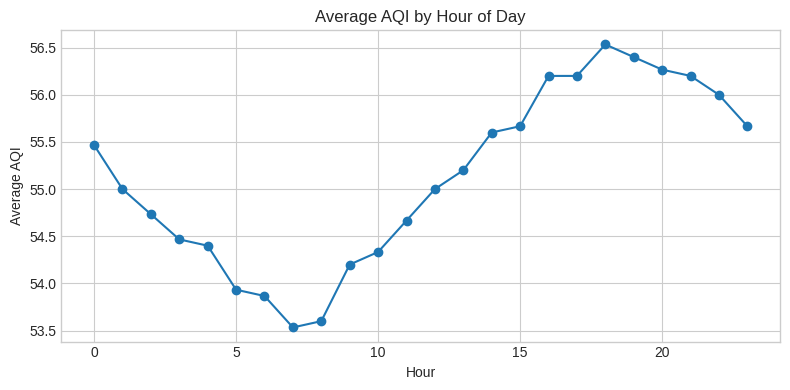

In [4]:
ax = hourly_pdf.plot(
    kind="line", x="hour", y="avg_aqi", marker="o", legend=False, figsize=(8, 4)
)
ax.set_title("Average AQI by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Average AQI")
plt.tight_layout()
plt.show()

In [5]:
daily_pdf = report_tables["daily_aqi"]
display(daily_pdf)

,day,avg_aqi
0,2026-04-18,57.266667
1,2026-04-19,57.541667
2,2026-04-20,52.250000
3,2026-04-21,54.708333
4,2026-04-22,57.916667
5,2026-04-23,52.875000
6,2026-04-24,53.875000
7,2026-04-25,58.000000
8,2026-04-26,53.541667
9,2026-04-27,53.208333


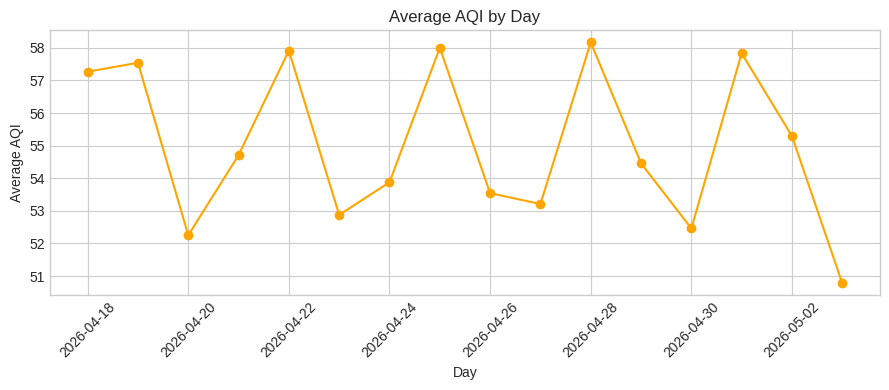

In [6]:
ax = daily_pdf.plot(
    kind="line",
    x="day",
    y="avg_aqi",
    marker="o",
    legend=False,
    figsize=(9, 4),
    color="orange",
)
ax.set_title("Average AQI by Day")
ax.set_xlabel("Day")
ax.set_ylabel("Average AQI")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## AQI Category Distribution

In [7]:
aqi_category_pdf = report_tables["aqi_category_distribution"]
display(aqi_category_pdf)

,aqi_category,count
0,Moderate,350
1,Good,10


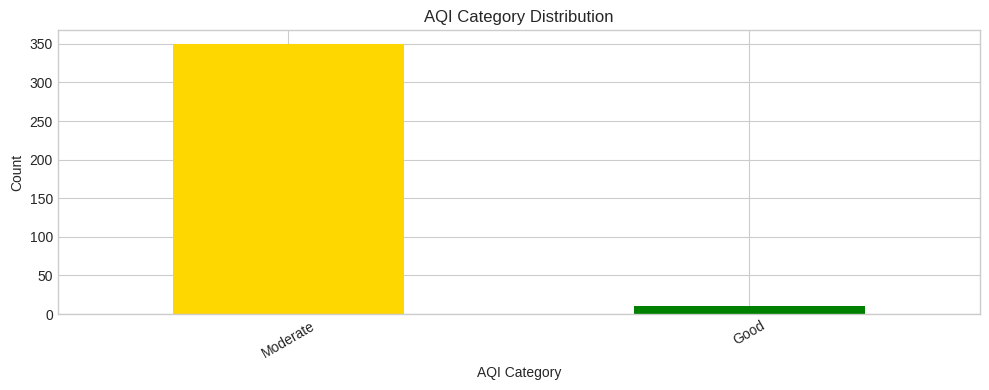

In [8]:
colors_map = {
    "Good": "green",
    "Moderate": "gold",
    "Unhealthy for Sensitive Groups": "orange",
    "Unhealthy": "red",
    "Very Unhealthy": "purple",
    "Hazardous": "maroon",
}
colors = [colors_map.get(cat, "gray") for cat in aqi_category_pdf["aqi_category"]]


ax = aqi_category_pdf.plot(
    kind="bar",
    x="aqi_category",
    y="count",
    legend=False,
    figsize=(10, 4),
    color=colors,
)
ax.set_title("AQI Category Distribution")
ax.set_xlabel("AQI Category")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Pollutant Profile

In [9]:
pollutants_pdf = report_tables["average_pollutants"]
display(pollutants_pdf)

,pollutant,avg_value,measurement_count
0,no2,12.057778,360
1,o3,32.000000,360
2,pm10,18.088889,360


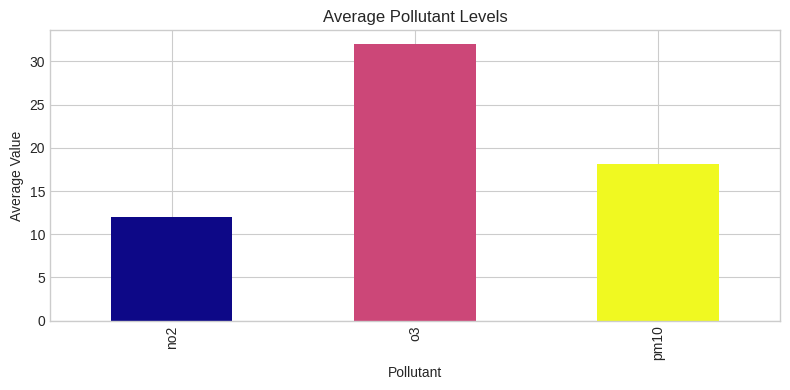

In [10]:
pollutant_values = pollutants_pdf.set_index("pollutant")["avg_value"]
ax = pollutant_values.plot(
    kind="bar",
    figsize=(8, 4),
    color=plt.cm.plasma(np.linspace(0, 1, len(pollutant_values))),
)
ax.set_title("Average Pollutant Levels")
ax.set_xlabel("Pollutant")
ax.set_ylabel("Average Value")
plt.tight_layout()
plt.show()

## Dominant Pollutants

In [11]:
dominant_pdf = report_tables["dominant_pollutants"]
display(dominant_pdf)

,dominant_pollutant,count
0,o3,332
1,pm10,28


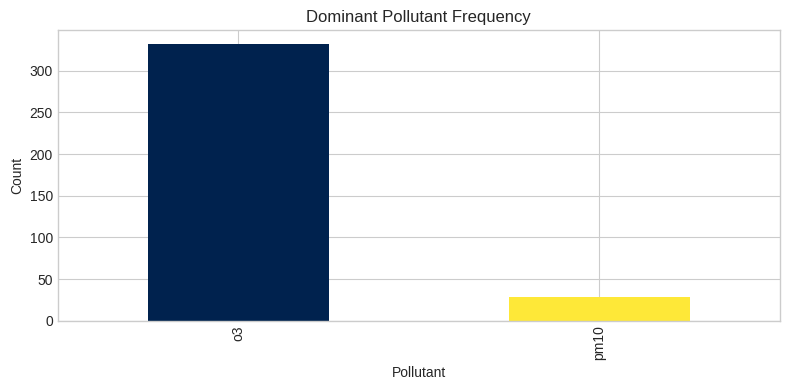

In [17]:
ax = dominant_pdf.plot(
    kind="bar",
    x="dominant_pollutant",
    y="count",
    legend=False,
    figsize=(8, 4),
    color=plt.cm.cividis(np.linspace(0, 1, len(dominant_pdf))),
)
ax.set_title("Dominant Pollutant Frequency")
ax.set_xlabel("Pollutant")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Weather Relationships

In [13]:
correlations_pdf = report_tables["weather_correlations"]
display(correlations_pdf)

,aqi_temperature_corr,aqi_humidity_corr,aqi_wind_corr
0,0.020897,-0.020906,0.000924


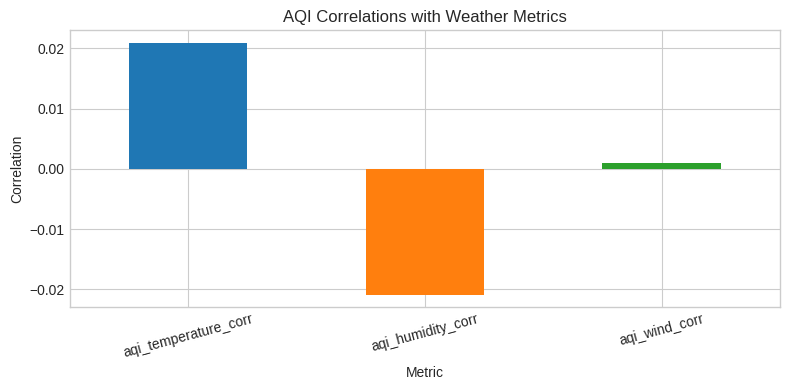

In [14]:
correlation_values = correlations_pdf.iloc[0]
ax = correlation_values.plot(
    kind="bar", figsize=(8, 4), color=["tab:blue", "tab:orange", "tab:green"]
)
ax.set_title("AQI Correlations with Weather Metrics")
ax.set_xlabel("Metric")
ax.set_ylabel("Correlation")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## Summary

In [15]:
peak_hour = hourly_pdf.loc[hourly_pdf["avg_aqi"].idxmax()]
peak_day = daily_pdf.loc[daily_pdf["avg_aqi"].idxmax()]
top_category = aqi_category_pdf.iloc[0]
top_pollutant = dominant_pdf.iloc[0]
correlation_values = correlations_pdf.iloc[0].dropna()
strongest_metric = correlation_values.abs().idxmax()

print(
    f"Highest average hourly AQI: {peak_hour['avg_aqi']:.1f} at hour {int(peak_hour['hour'])}."
)
print(f"Highest average daily AQI: {peak_day['avg_aqi']:.1f} on {peak_day['day']}.")
print(
    f"Most common AQI category: {top_category['aqi_category']} ({int(top_category['count'])} records)."
)
print(
    f"Most common dominant pollutant: {top_pollutant['dominant_pollutant']} ({int(top_pollutant['count'])} records)."
)
print(
    f"Strongest AQI-weather relationship by absolute correlation: {strongest_metric} = {correlation_values[strongest_metric]:.3f}."
)

Highest average hourly AQI: 56.5 at hour 18.
Highest average daily AQI: 58.2 on 2026-04-28.
Most common AQI category: Moderate (350 records).
Most common dominant pollutant: o3 (332 records).
Strongest AQI-weather relationship by absolute correlation: aqi_humidity_corr = -0.021.
